# iscc overview

`iscc` simulates the whole journey from tumor biology to observed molecular data as **three composable stages**:

| Step | CLI | Produces |
|---|---|---|
| 1. Growth | `isccsim` | a tumor's ground-truth per-cell state |
| 2. Sampling | `isccsample` | a biopsy / dissociation (subset of cells) |
| 3. Assay | `isccdata` | observed sequencing / spatial data |

This notebook runs all three with the **Python API** (and shows the equivalent CLI at the end). For deeper dives see [Exploring the tumor](02_tumor_growth.ipynb) and [Exploring the data](03_data_overview.ipynb).

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import iscc

NB_DIR = os.getcwd()
CONFIG = os.path.join(NB_DIR, "example_config.yaml")
print("iscc from:", iscc.__file__)

iscc from: /Users/pedroferreira/projects/iscc/repo/src/iscc/__init__.py


## Grow a tumor

We build a spatial `GenotypeTumor` from a YAML config and grow it. The config sets the spatial mode, genome size, the CINner-style selection parameters, and per-cell-type rates.

In [2]:
from iscc.tumor.models import GenotypeTumor

# One cm-scale tissue (~8.5 mm, ~10^6 cells): a single-clonal-founder DCIS -> confluent-IDC breast sample.
# Growing to the DCIS->IDC state takes ~5 min (tau-leaping + passenger coarsening make cm-scale feasible).
tumor = GenotypeTumor(config=CONFIG, seed=2)
for _ in range(30):                       # grow to the confluent DCIS->IDC of the landing hero
    tumor.grow(n_steps=20, seed=2)        # (~190k cancer); R15 makes invasion a slow, breach-gated
    if tumor.get_cancer_size() >= 150_000:  # transition, so grow until it coalesces, not a fixed
        break                             # early step count (the ducts saturate ~24k on their own)
print(f"Tumor: {tumor.get_cancer_size()} cancer / {tumor.get_tumor_size()} total cells "
      f"across {len(tumor.demes)} demes ({tumor.grid_size} x {tumor.grid_size} ~ 8.5 mm)")

Tumor: 192768 cancer / 458364 total cells across 28900 demes (170 x 170 ~ 8.5 mm)


### What the config sets — and the physical scale

`example_config.yaml` defines this tissue. Three things are worth reading off it:

- **A deme is not a cell.** The engine's spatial unit is a **deme** (~50 µm) — a small 3-D *column* of
  tissue, not one cell. Its carrying capacity `K` is that column's cell population (`K_duct` 60 in a
  dense duct, `K_stroma` 30 in stroma); that is how a 2-D grid captures 3-D depth. A histology or
  Visium section samples only a thin *slice* of each column.
- **The sizes are realistic.** grid 170 × ~50 µm ≈ **8.5 mm** of tissue (~0.5 M cells grown, ~10⁶ at capacity) — deliberately
  *larger* than a 6.5 mm Visium capture, so every assay samples a subset. A DCIS duct is `gland_radius`
  4 → 9 demes ≈ **450 µm**; one Visium spot ≈ 55 µm ≈ one deme.
- **The biology is one clonal founder, DCIS → IDC.** `selection_params`/`cell_params` set CINner-style
  fitness (oncogene/TSG copy-number drivers) and rare, strong invasion: crossing the duct wall
  (`breach`) is rare, but the stroma is permissive, so an escaped clone invades and spreads along the
  connected ducts. `n_steps` sets how far invasion has coalesced — all the invasive tissue is **one
  clone**. Tau-leaping (`update_mode: tau`) + `coarsen_passengers` make cost scale with clones × demes,
  not cells, which is what makes ~10⁶ cells affordable.

### Visualise growth and spatial structure

Three views of the **same tumour**, sharing one colouring so they line up: the tissue grid shows
*where* clones sit (space), the Muller shows *when* they swept (time), and the phylogeny shows *who
descends from whom* (ancestry). Clones are coloured by their **driver clone** — the distinct set of
driver (oncogene/TSG) mutations they carry (`by_drivers`) — so a clone keeps its colour across all
three.

The grid below also has a **stage** view: instead of driver identity, it colours each region by the
*stage-dominant trait* its clone has reached (none → proliferation → invasion). That's the same scheme
the [landing animation](../index.md) uses to show the full metastatic cascade — here, with no
metastasis or treatment, it just reads out the DCIS → IDC progression.

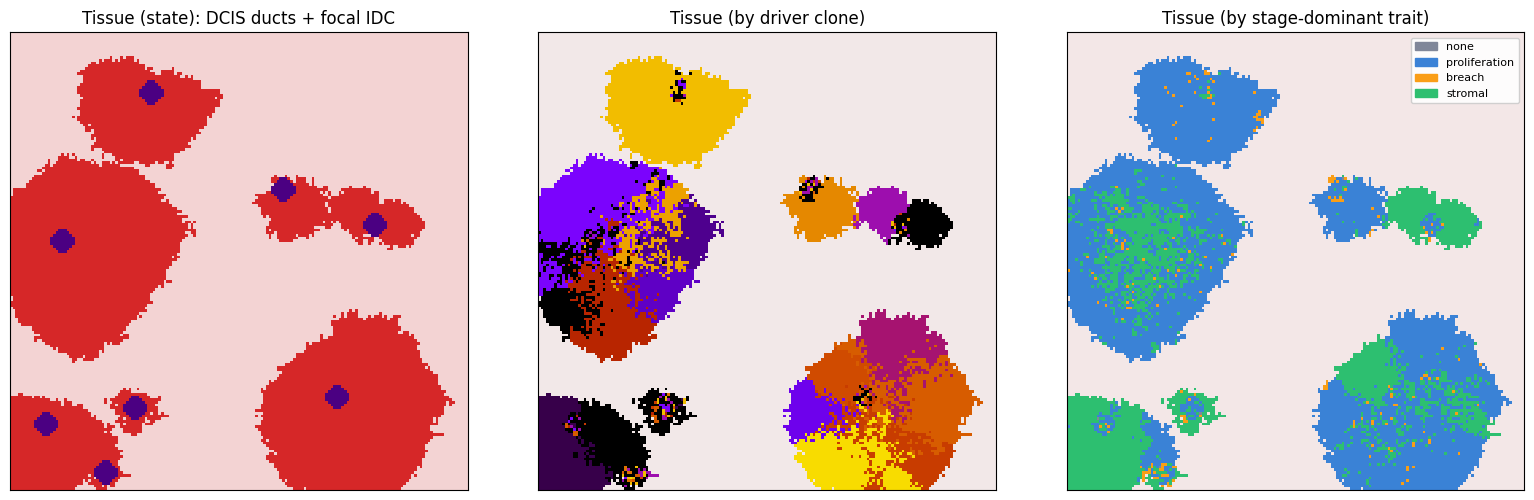

In [3]:
# plot_tissue draws the deme grid from the per-deme COUNTS, so it stays complete at cm-scale even
# though cell_data is a memory-safe subsample. "state" is categorical histology; "clone" colours each
# cancer deme by its dominant driver clone (matching the Muller + phylogeny); "stage" colours it by the
# stage-dominant trait (none / proliferation / invasion) — the SAME scheme the landing animation uses.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
tumor.plot_tissue(ax=axes[0], color="state")
axes[0].set_title("Tissue (state): DCIS ducts + focal IDC")
tumor.plot_tissue(ax=axes[1], color="clone")
axes[1].set_title("Tissue (by driver clone)")
tumor.plot_tissue(ax=axes[2], color="stage")
axes[2].set_title("Tissue (by stage-dominant trait)")
plt.tight_layout()

The Muller (time) and the phylogeny (ancestry) complete the trio, in the same driver-clone colours.
`by_drivers` collapses passenger-only diversity to a handful of driver clades; the Muller shows their
frequencies over time and the phylogeny shows how they descend from the founder — the same clades you
see tiling the grid.

Text(0.5, 1.0, 'Clonal dynamics (Muller, by driver clone) — a single founder + its subclones')

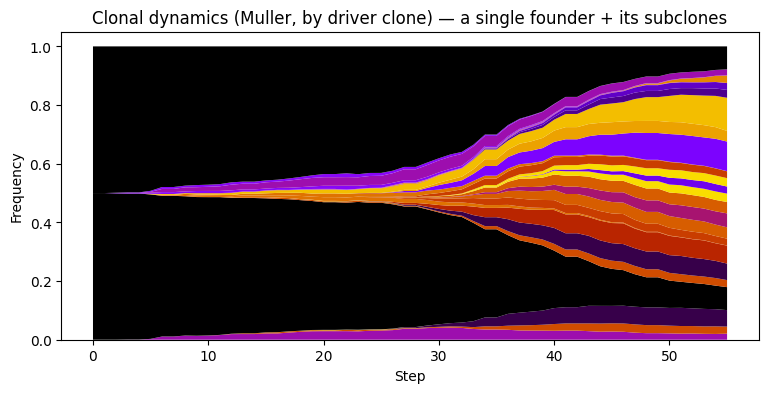

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
tumor.plot_muller(ax=ax, by_drivers=True, min_freq=0.02)
ax.set_title("Clonal dynamics (Muller, by driver clone) — a single founder + its subclones")

Text(0.5, 1.0, 'Clade phylogeny (by driver clone)')

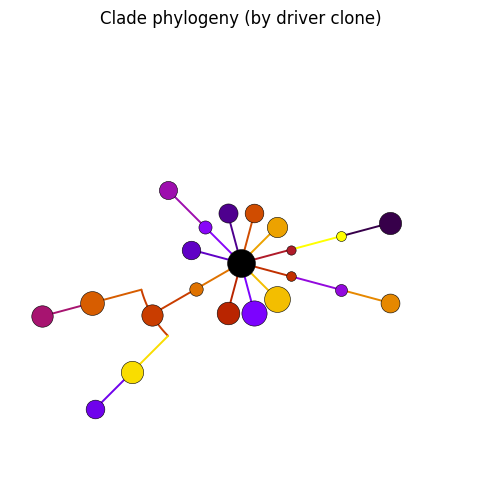

In [5]:
# Radial CLADE phylogeny, drawn straight to the axes (no image file). Rather than subsampling cells,
# the population is collapsed to driver clones (the same collapse the Muller uses) — one node per clade,
# sized by cell count, in the SAME driver-clone colours as the Muller and the grid.
fig, ax = plt.subplots(figsize=(6, 6))
tumor.plot_phylogeny(ax=ax)
ax.set_title("Clade phylogeny (by driver clone)")

### The ground truth

The per-cell ground truth lives in `tumor.cell_data` (a dict of DataFrames, also written to `cell_data/` by `tumor.write(path)`). These matrices are what later stages sample and sequence.

In [6]:
cd = tumor.cell_data
print("cell_data matrices:", list(cd.keys()))
cd["cell_snv"].iloc[:5, :6]

cell_data matrices: ['cell_evo', 'cell_snv', 'cell_cnv', 'cell_exp', 'cell_crd', 'cell_type', 'cell_deme', 'cell_rna_vaf', 'cell_wgd', 'cell_gland']


,G_0_0,G_0_1,G_0_2,G_0_3,G_0_4,G_0_5
C0,0.0,0.0,0.0,0.0,0.0,0.0
C1,0.0,0.0,0.0,0.0,0.0,0.0
C2,0.0,0.0,0.0,0.0,0.0,0.0
C3,0.0,0.0,0.0,0.0,0.0,0.0
C4,0.0,0.0,0.0,0.0,0.0,0.0


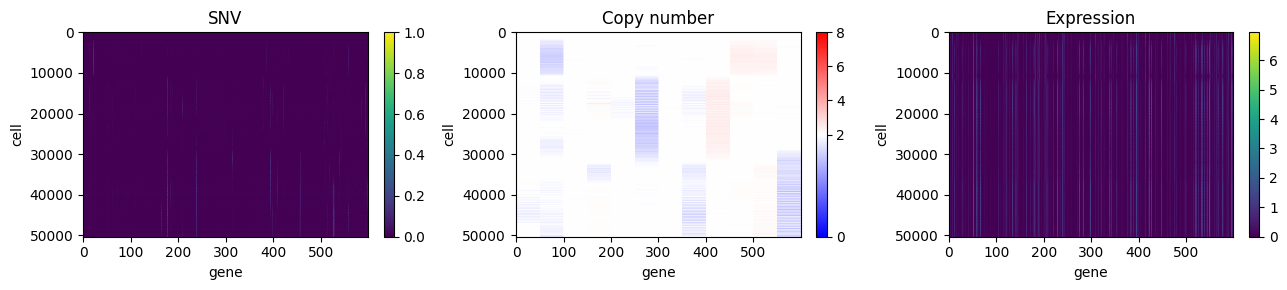

In [7]:
from iscc.tumor.viz import CNV_CMAP, cnv_norm
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, key, title in zip(axes, ["cell_snv", "cell_cnv", "cell_exp"], ["SNV", "Copy number", "Expression"]):
    if key == "cell_cnv":  # copy number: blue-white-red, white at diploid (2)
        im = ax.imshow(cd[key].values, aspect="auto", cmap=CNV_CMAP, norm=cnv_norm(cd[key].values))
    else:
        im = ax.imshow(cd[key].values, aspect="auto", cmap="viridis")
    ax.set_title(title); ax.set_xlabel("gene"); ax.set_ylabel("cell")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

## Sample the tumor

We **resect** the whole tumor (the specimen), then physically cut it for the assays.
`iscc.sample.Resection` makes the cuts: an **in-plane cut** (`bisect`) takes one 2-D part of the
tissue, which we **dissociate** (`dissociate`) into cells for the sequencing assays — losing spatial
position, exactly as a real dissociation does. (A thin **depth slice** of the remainder feeds a
spatial assay like Visium; that's the [data tutorial](03_data_overview.ipynb).) For more targeted
sampling, iscc also has spatially-realistic `Biopsy` geometries — punch / needle / multi-region /
liquid — over the same `cell_crd` grid.

In [8]:
from iscc.sample import Resection

# Resect the specimen, then cut a part of it and dissociate that part into cells for the sequencing
# assays. Dissociating a whole cut (not a punch hunting for the lesion) is representative: a spatial half of
# the specimen (subsampled to 50k cells), spanning DCIS ducts and invasive stroma alike.
spec = Resection(tumor)
cut, remainder = spec.bisect(frac=0.5, axis="x")        # in-plane cut: dissociate | keep for imaging
sample = spec.dissociate(cut, max_cells=50000)          # dissociate the cut -> cells for sequencing
n_can = int(sample["cell_type"]["cell_id"].map(lambda g: tumor.genotypes[g].type == "cancer").sum())
print(f"dissociated cut: {len(sample['cell_snv'])} cells "
      f"({n_can} cancer, {len(sample['cell_snv']) - n_can} microenvironment)")

dissociated cut: 50245 cells (23457 cancer, 26788 microenvironment)


Text(0.5, 1.0, 'Resected specimen — the dissociation cut')

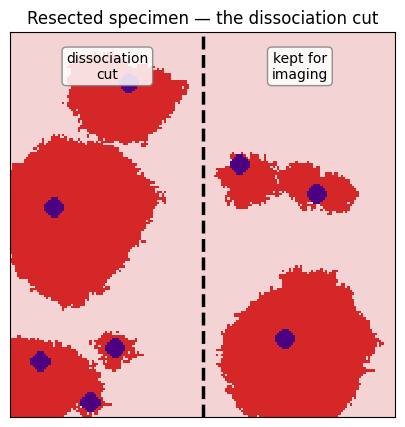

In [9]:
# The dissociation cut is a spatial PART of the specimen (the rest is kept for imaging):
split = int(0.5 * tumor.grid_size)
fig, ax = plt.subplots(figsize=(5, 5))
tumor.plot_tissue(ax=ax, color="state")
ax.axvline(split - 0.5, color="k", lw=2.5, ls="--")
ax.text(split * 0.5, 8, "dissociation\ncut", ha="center", va="top",
        bbox=dict(boxstyle="round", fc="white", ec="0.5", alpha=0.85))
ax.text(split + (tumor.grid_size - split) * 0.5, 8, "kept for\nimaging", ha="center", va="top",
        bbox=dict(boxstyle="round", fc="white", ec="0.5", alpha=0.85))
ax.set_title("Resected specimen — the dissociation cut")

## Run molecular assays

Each assay turns the sampled cells' ground truth into observed data. The assays live in `iscc.data`.

In [10]:
from iscc.data import scRNA, bulkDNA

sc_assay = scRNA(n_reads=3000, n_cells=300)
sc_assay.run(sample)
print("scRNA UMI matrix:", sc_assay.observed_counts.shape)
sc_assay.observed_counts.iloc[:5, :6]

scRNA UMI matrix: (300, 600)


,G_0_0,G_0_1,G_0_2,G_0_3,G_0_4,G_0_5
C25641,0,7,28,0,0,0
C39080,27,0,0,17,0,0
C50165,19,0,0,0,0,0
C50229,12,0,0,14,0,0
C4512,0,5,21,0,0,0


Text(0.5, 1.0, 'Bulk DNA VAF spectrum')

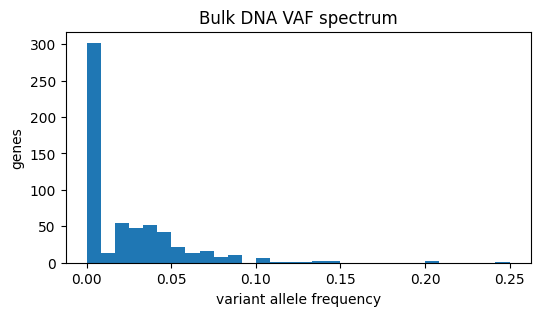

In [11]:
bd = bulkDNA(n_reads=20000, data_mode="counts", fpr=0.02, fnr=0.02)
bd.run(sample)
cov = bd.observed_data["coverage"].replace(0, np.nan)
vaf = (bd.observed_data["alt_counts"] / cov).dropna()
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(vaf, bins=30)
ax.set_xlabel("variant allele frequency"); ax.set_ylabel("genes")
ax.set_title("Bulk DNA VAF spectrum")

## The same pipeline from the command line

The same grow → sample → assay steps as commands (the CLI takes a punch biopsy rather than the
notebook's `Resection` cut, so the exact sampled cells differ):

```bash
isccsim    --sim-config example_config.yaml -r 2 -s 320 -o example_out/tumor
isccsample example_out/tumor --method biopsy --biopsy-type punch -o example_out/sample
isccdata   example_out/sample -a scrna --assay-config ../src/iscc/data/assayconfigs/scrna.yaml -o example_out/data_scrna
```
**Next:** [Exploring the tumor](02_tumor_growth.ipynb) · [Exploring the data](03_data_overview.ipynb).